## Markwow chain calculations
  System with transitions between lowest state and highest stated with options for moving up with $p_u$ and down with $1-p_u$. In case of going down there is an optional chance to remain at the same state.
  
   Initializes a new $n x n $ transition matrix with function TransitionMatrixN(n) the final state distibution is then initial state matrix multiplied by the transition matrix. Flexible functions can simulate nxn size chains with different lenfths.



In [1]:
import numpy as np

#model parameters

#p_u = 0.53 #move up
#t = 0.05 # incase of not moving up remain in place
#p_d = (1-p_u)*(1-t) #move down
#p_s = t*(1-p_u) # remain in place

def TransitionMatrixN(n,p_u=0.53,t=0.05):
    #generate transition matrix for n states with given parameterts
    # where p_u is the probability of moving up, t is the probability of remaining in place if not moving up,
    p_d = (1-p_u)*(1-t) #move down
    p_s = t*(1-p_u) # remain in place
    matrix = np.zeros((n,n))
    #manually initialize first and last rows with only 2 options
    matrix[0,0]=p_s+p_d #remain in place as cannot go down
    matrix[0,1]=p_u #move up
    matrix[n-1,n-1]= p_s+p_d+p_u # final position reached 

    for i in range(1,(n-1)):
        for j in range(n):
            if i ==j:
                matrix[i,j]=p_s #remain in place
            elif i ==j-1:
                matrix[i,j]=p_u #up
            elif i ==j+1:
                matrix[i,j]=p_d #down
    return matrix
            

        

def nStepsTransitionM(n,steps,p_u=0.53,t=0.05):
    matrix = TransitionMatrixN(n, p_u, t)
    return np.linalg.matrix_power(matrix,steps)

# initial state vector
def initialState(n):
    state = np.zeros(n)
    state[0] = 1  # start at the first position
    return state

def final_state_distribution(n,steps,p_u=0.53,t=0.05):
    return initialState(n).dot(nStepsTransitionM(n, steps, p_u, t)) 


In [3]:
print(TransitionMatrixN(12))   
print(nStepsTransitionM(12,10))

[[0.47   0.53   0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.    ]
 [0.4465 0.0235 0.53   0.     0.     0.     0.     0.     0.     0.
  0.     0.    ]
 [0.     0.4465 0.0235 0.53   0.     0.     0.     0.     0.     0.
  0.     0.    ]
 [0.     0.     0.4465 0.0235 0.53   0.     0.     0.     0.     0.
  0.     0.    ]
 [0.     0.     0.     0.4465 0.0235 0.53   0.     0.     0.     0.
  0.     0.    ]
 [0.     0.     0.     0.     0.4465 0.0235 0.53   0.     0.     0.
  0.     0.    ]
 [0.     0.     0.     0.     0.     0.4465 0.0235 0.53   0.     0.
  0.     0.    ]
 [0.     0.     0.     0.     0.     0.     0.4465 0.0235 0.53   0.
  0.     0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.4465 0.0235 0.53
  0.     0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.4465 0.0235
  0.53   0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.4465
  0.0235 0.53  ]
 [0.     0.     0.     0.     0.     0.     0.     0.  

In [6]:
#final state distribution after 10 steps of the markow chain
n = 20
t = 20
print(final_state_distribution(n,t,0.4,0))

print(sum(final_state_distribution(n,t,0.4,0))) # should be 1 as it is a probability distribution   


[3.68920618e-01 2.38847591e-01 1.59231727e-01 9.43220050e-02
 6.28813367e-02 3.28189835e-02 2.18793224e-02 9.73186420e-03
 6.48790947e-03 2.38353269e-03 1.58902180e-03 4.66038333e-04
 3.10692222e-04 6.96410908e-05 4.64273939e-05 7.44953488e-06
 4.96635658e-06 5.07149738e-07 3.21607151e-07 4.39804651e-08]
1.0


# Expected iterations to reach the final state

Comparing strategies in a game where you can either have higher winrate or lower winrate but less downside on a loss.

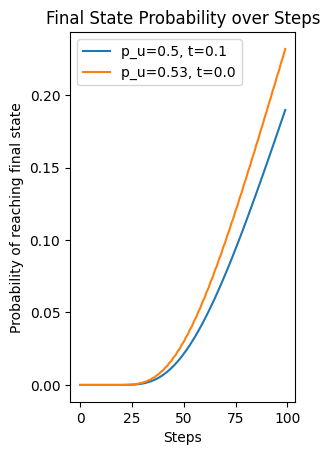

In [20]:
k = 100 # length of markow chain
n = 20 # number of states
p_u = 0.51 #probability of moving up
t = 0.01 #probability of remaining in place if not moving up
final_state_p = np.zeros((100,2)) #store results for different parameters

params = np.array([[0.50,0.1],[0.53,0.00]])
for idx, j in enumerate(params):
    p_u = j[0] #winrate
    t = j[1]  #
    for i in range(k):
        final_state_p[i, idx] = final_state_distribution(n,i,p_u,t)[-1]

#plot the change
import matplotlib.pyplot as plt

plt.subplot(1,2,1)
plt.plot(final_state_p[:,0], label=f'p_u={params[0,0]}, t={params[0,1]}')
plt.plot(final_state_p[:,1], label=f'p_u={params[1,0]}, t={params[1,1]}')
plt.xlabel('Steps')
plt.ylabel('Probability of reaching final state')
plt.title('Final State Probability over Steps')

plt.legend()